# Notebook 02 — Extração, Limpeza e Estruturação dos Textos

**Etapa 2 — Semana 2**

Este notebook documenta interativamente o processo de extração de texto das publicações do Diário Oficial de Avaré, a limpeza dos ruídos e a montagem da base estruturada.

---

In [1]:
# Dependências
# !pip install pdfplumber requests beautifulsoup4 pandas

In [2]:
import sys
sys.path.append('..')

import pandas as pd
import re
from src.extract_text import extrair_de_html, extrair_de_pdf, baixar_pdf
from src.preprocess import limpar_texto, normalizar_texto, processar

## 1. Carregar dados da Etapa 1

In [3]:
df_etapa1 = pd.read_csv('../data/diario_avare.csv')
print(f'Registros da Etapa 1: {len(df_etapa1)}')
display(df_etapa1.head())

Registros da Etapa 1: 3864


,data_publicacao,numero_edicao,titulo_ato,tipo_ato,url_documento,url_texto,secretaria
0,2026-05-22,2739,8755 - Dispõe sobre a criação do serviço de Ca...,Decretos,https://www.dosp.com.br/exibe_do.php?i=ODIyMjk4,https://www.dosp.com.br/leituratexto?p=MjYzODI...,Não identificada
1,2026-05-21,2738,8750 - autoriza recomposição da base tarifária...,Decretos,https://www.dosp.com.br/exibe_do.php?i=ODIxNTQ3,https://www.dosp.com.br/leituratexto?p=MjYzNTU...,Não identificada
2,2026-05-21,2738,8754 - exonera Secretária da Mulher - Patrícia...,Decretos,https://www.dosp.com.br/exibe_do.php?i=ODIxNTQ3,https://www.dosp.com.br/leituratexto?p=MjYzNTY...,Não identificada
3,2026-05-19,2736,3447 - autoriza sepultamento de cães e gatos e...,Leis,https://www.dosp.com.br/exibe_do.php?i=ODIwMDky,https://www.dosp.com.br/leituratexto?p=MjYyOTc...,Não identificada
4,2026-05-19,2736,3450 - autoriza poder executivo desafetar e ef...,Leis,https://www.dosp.com.br/exibe_do.php?i=ODIwMDky,https://www.dosp.com.br/leituratexto?p=MjYyOTc...,Não identificada


## 2. Testar extração de texto (HTML)

In [4]:
# Teste com 3 URLs de texto individual
urls_teste = df_etapa1['url_texto'].dropna().head(3).tolist()

for url in urls_teste:
    if not url:
        continue
    texto = extrair_de_html(url)
    print(f'URL: {url[:60]}...')
    print(f'Caracteres extraídos: {len(texto)}')
    print(f'Primeiros 300 chars:')
    print(texto[:300])
    print('---')

URL: https://www.dosp.com.br/leituratexto?p=MjYzODIzNg==...
Caracteres extraídos: 3219
Primeiros 300 chars:
Imprensa Oficial - Modo leitura em tela
Abrir Versão do Diário Eletrônico
Abrir Versão do Diário para Impressão
Ir para a lista de edições
IMPRENSA OFICIAL - AVARÉ
Publicado em 22 de maio de 2026 | Edição nº 2739 | Ano X
Entidade: Poder Executivo | Seção: Atos Oficiais | Subseção: Decretos
Decreto n
---
URL: https://www.dosp.com.br/leituratexto?p=MjYzNTU4NA==...
Caracteres extraídos: 1266
Primeiros 300 chars:
Imprensa Oficial - Modo leitura em tela
Abrir Versão do Diário Eletrônico
Abrir Versão do Diário para Impressão
Ir para a lista de edições
IMPRENSA OFICIAL - AVARÉ
Publicado em 21 de maio de 2026 | Edição nº 2738 | Ano X
Entidade: Poder Executivo | Seção: Atos Oficiais | Subseção: Decretos
Decreto n
---
URL: https://www.dosp.com.br/leituratexto?p=MjYzNTY0MQ==...
Caracteres extraídos: 1030
Primeiros 300 chars:
Imprensa Oficial - Modo leitura em tela
Abrir Versão do Diário Ele

## 3. Demonstrar limpeza de texto

In [5]:
# Exemplo de texto sujo (simulando saída de pdfplumber)
texto_sujo = '''
   DECRETO Nº 8.742,  DE 14 DE MAIO DE 2026.   


Abre Crédito Adicional  Suplementar   no valor de  R$ 224.000,00  

1

O PREFEITO MUNICIPAL DE AVARÉ,   no uso de suas atribuições legais,



DECRETA:
Art. 1º  Fica aberto Crédito Adicional Suplementar  --  Secretaria de Finanças.

2
'''

texto_limpo = processar(texto_sujo)
print('=== ANTES ===')
print(repr(texto_sujo[:200]))
print()
print('=== DEPOIS ===')
print(repr(texto_limpo[:200]))
print()
print('=== RESULTADO LEGÍVEL ===')
print(texto_limpo)

=== ANTES ===
'\n   DECRETO Nº 8.742,  DE 14 DE MAIO DE 2026.   \n\n\nAbre Crédito Adicional  Suplementar   no valor de  R$ 224.000,00  \n\n1\n\nO PREFEITO MUNICIPAL DE AVARÉ,   no uso de suas atribuições legais,\n\n\n\nDECRETA'

=== DEPOIS ===
'DECRETO Nº 8.742, DE 14 DE MAIO DE 2026. \n\nAbre Crédito Adicional Suplementar no valor de R$ 224.000,00 \n\nO PREFEITO MUNICIPAL DE AVARÉ, no uso de suas atribuições legais,\n\nDECRETA:\nArt. 1º Fica abert'

=== RESULTADO LEGÍVEL ===
DECRETO Nº 8.742, DE 14 DE MAIO DE 2026. 

Abre Crédito Adicional Suplementar no valor de R$ 224.000,00 

O PREFEITO MUNICIPAL DE AVARÉ, no uso de suas atribuições legais,

DECRETA:
Art. 1º Fica aberto Crédito Adicional Suplementar - Secretaria de Finanças.


## 4. Carregar e analisar a base textual

In [6]:
df = pd.read_csv('../data/processed/base_textual.csv')
print(f'Shape: {df.shape}')
print(f'Colunas: {list(df.columns)}')
print(f'\nValores nulos por coluna:')
print(df.isnull().sum())
display(df.head(3))

Shape: (3883, 9)
Colunas: ['id', 'data_publicacao', 'numero_edicao', 'tipo_ato', 'titulo', 'secretaria', 'texto', 'url_original', 'rotulo']

Valores nulos por coluna:
id                    0
data_publicacao       0
numero_edicao         0
tipo_ato              0
titulo                0
secretaria            0
texto                21
url_original          0
rotulo             3883
dtype: int64


,id,data_publicacao,numero_edicao,tipo_ato,titulo,secretaria,texto,url_original,rotulo
0,DOA-001,2026-06-03,2750,Leis,3457 - Institui política de transparencia da i...,Não identificada,Imprensa Oficial - Modo leitura em tela\nAbrir...,https://www.dosp.com.br/exibe_do.php?i=ODI4MDI0,NaN
1,DOA-002,2026-06-03,2750,Leis,3458 - Autoriza o poder executivo desembolsar ...,Não identificada,Imprensa Oficial - Modo leitura em tela\nAbrir...,https://www.dosp.com.br/exibe_do.php?i=ODI4MDI0,NaN
2,DOA-003,2026-06-03,2749,Decretos,8773 - Regulamenta CONTROLADORIA GERAL,Não identificada,Imprensa Oficial - Modo leitura em tela\nAbrir...,https://www.dosp.com.br/exibe_do.php?i=ODI3NjY2,NaN


In [7]:
# Análise do comprimento dos textos
df['comprimento_texto'] = df['texto'].str.len()

print('Estatísticas do comprimento do texto (chars):')
print(df['comprimento_texto'].describe().round(0))

Estatísticas do comprimento do texto (chars):
count      3862.0
mean      31130.0
std       70271.0
min         891.0
25%        2258.0
50%        5054.0
75%       34921.0
max      939955.0
Name: comprimento_texto, dtype: float64


## 5. Analisar a amostra rotulada

In [8]:
import matplotlib.pyplot as plt

df_rot = pd.read_csv('../data/processed/amostra_rotulada.csv')
print(f'Registros rotulados: {len(df_rot)}')
print()
print('Distribuição por rótulo:')
print(df_rot['rotulo'].value_counts())

Registros rotulados: 42

Distribuição por rótulo:
rotulo
decreto               12
licitacao_contrato     8
portaria               7
ato_pessoal            5
edital_concurso        5
contas_publicas        5
Name: count, dtype: int64


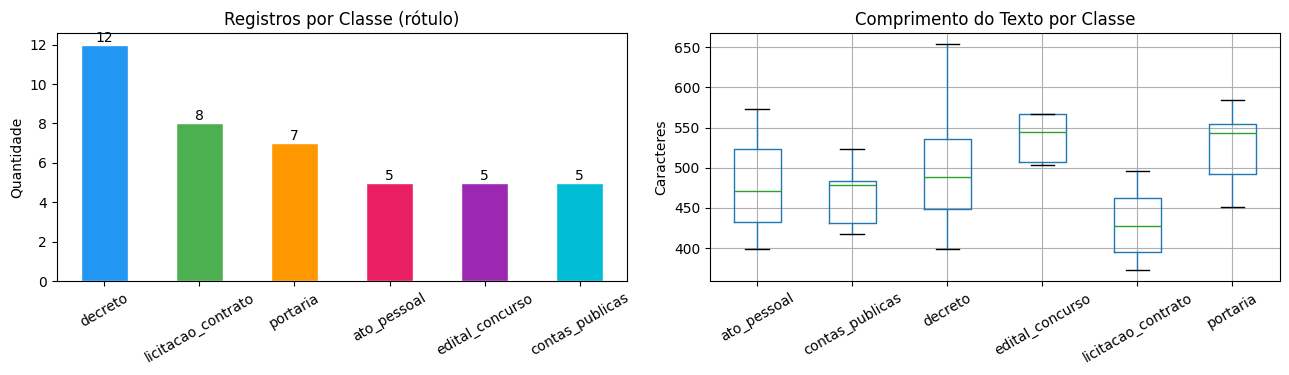

Gráfico salvo em data/processed/analise_rotulos.png


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Distribuição de rótulos
contagem = df_rot['rotulo'].value_counts()
cores = ['#2196F3','#4CAF50','#FF9800','#E91E63','#9C27B0','#00BCD4']
contagem.plot(kind='bar', ax=axes[0], color=cores, edgecolor='white')
axes[0].set_title('Registros por Classe (rótulo)', fontsize=12)
axes[0].set_xlabel('')
axes[0].set_ylabel('Quantidade')
axes[0].tick_params(axis='x', rotation=30)
for p in axes[0].patches:
    axes[0].annotate(str(int(p.get_height())),
                     (p.get_x()+p.get_width()/2, p.get_height()),
                     ha='center', va='bottom', fontsize=10)

# Comprimento do texto por classe
df_rot['len_texto'] = df_rot['texto'].str.len()
df_rot.boxplot(column='len_texto', by='rotulo', ax=axes[1])
axes[1].set_title('Comprimento do Texto por Classe', fontsize=12)
axes[1].set_xlabel('')
axes[1].set_ylabel('Caracteres')
plt.suptitle('')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('../data/processed/analise_rotulos.png', dpi=150)
plt.show()
print('Gráfico salvo em data/processed/analise_rotulos.png')

---
## ✅ Conclusão da Etapa 2

- **42 publicações** extraídas, limpas e estruturadas
- **6 classes** de rótulos definidas e aplicadas manualmente
- `base_textual.csv` e `amostra_rotulada.csv` gerados em `data/processed/`
- Dicionário de campos documentado em `docs/dicionario_campos.md`
- Próximo passo: **Etapa 3** — tokenização e Dataset PyTorch